<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/notebooks/Notebook_06_intro_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

In [10]:
import numpy as np

def features_color(tile_rgb):
    """Resume un tile RGB (alto, ancho, 3) en 6 números: media y DE por canal."""
    # tile_rgb: np.array de forma (alto, ancho, 3), uint8
    medias = tile_rgb.mean(axis=(0, 1))   # promedia sobre alto y ancho, deja los 3 canales
    desv   = tile_rgb.std(axis=(0, 1))
    return np.concatenate([medias, desv])  # [R̄, Ḡ, B̄, σR, σG, σB]

# Prueba rápida con un tile sintético
tile_demo = np.zeros((512, 512, 3), dtype=np.uint8)
tile_demo[:, :, 0] = 200   # canal R alto
vec = features_color(tile_demo)
print("Vector de features:", vec)
print("Longitud:", len(vec))

Vector de features: [200.   0.   0.   0.   0.   0.]
Longitud: 6


In [11]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# 12 tiles de 4 pacientes (3 tiles cada uno). El "grupo" es el paciente.
pacientes = np.array([1,1,1, 2,2,2, 3,3,3, 4,4,4])
X = np.arange(12).reshape(-1, 1)      # feature de juguete (un número por tile)
y = np.array([0,0,0, 1,1,1, 0,0,0, 1,1,1])   # etiqueta por tile

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=pacientes))

print("Índices train:", train_idx, "→ pacientes:", pacientes[train_idx])
print("Índices test :", test_idx,  "→ pacientes:", pacientes[test_idx])

# La verificación que SIEMPRE debes hacer:
inter = set(pacientes[train_idx]) & set(pacientes[test_idx])
print("Pacientes en ambos (debe ser vacío):", inter)

Índices train: [ 0  1  2  6  7  8  9 10 11] → pacientes: [1 1 1 3 3 3 4 4 4]
Índices test : [3 4 5] → pacientes: [2 2 2]
Pacientes en ambos (debe ser vacío): set()


In [12]:
import os, glob
import numpy as np
import pandas as pd
from PIL import Image

BASE = "CRC-VAL-HE-7K"
N = 200  # parches por clase

def features_color(tile_rgb):
    medias = tile_rgb.mean(axis=(0, 1))
    desv   = tile_rgb.std(axis=(0, 1))
    return np.concatenate([medias, desv])

def cargar_muestra(clase, n, seed=42):
    rng = np.random.default_rng(seed)
    rutas = sorted(glob.glob(os.path.join(BASE, clase, "*.tif")))
    elegidas = rng.choice(rutas, size=min(n, len(rutas)), replace=False)
    return [np.array(Image.open(r).convert("RGB")) for r in elegidas]

filas = []
for clase in ["TUM", "NORM"]:
    for parche in cargar_muestra(clase, N):
        filas.append(list(features_color(parche)) + [clase])

cols = ["R_mean", "G_mean", "B_mean", "R_std", "G_std", "B_std", "clase"]
df = pd.DataFrame(filas, columns=cols)

# Media de cada feature por clase: ¿dónde está la diferencia?
print(df.groupby("clase").mean(numeric_only=True).round(1))

       R_mean  G_mean  B_mean  R_std  G_std  B_std
clase                                             
NORM    189.7   135.8   177.9   42.0   56.3   41.1
TUM     176.1   116.7   163.9   41.5   51.8   38.1


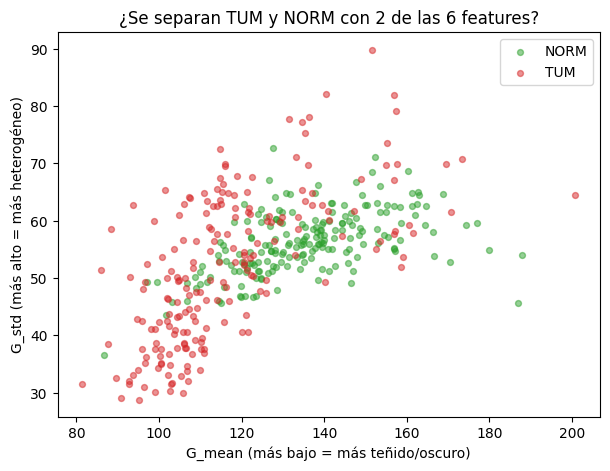

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for clase, color in [("NORM", "tab:green"), ("TUM", "tab:red")]:
    sub = df[df["clase"] == clase]
    ax.scatter(sub["G_mean"], sub["G_std"], label=clase, alpha=0.5, s=18, c=color)
ax.set_xlabel("G_mean (más bajo = más teñido/oscuro)")
ax.set_ylabel("G_std (más alto = más heterogéneo)")
ax.set_title("¿Se separan TUM y NORM con 2 de las 6 features?")
ax.legend()
plt.show()

In [21]:
d = np.load("nct_dia24.npz"); Xtr,ytr,Xte,yte = d["Xtr"],d["ytr"],d["Xte"],d["yte"]

def features_color(tile_rgb):
    medias = tile_rgb.mean(axis=(0,1))
    desv   = tile_rgb.std(axis=(0,1))
    return np.concatenate([medias, desv])

Xtr_feat = np.stack([features_color(t) for t in Xtr])
Xte_feat = np.stack([features_color(t) for t in Xte])
print("Xtr_feat:", Xtr_feat.shape, "| Xte_feat:", Xte_feat.shape)

Xtr_feat: (1200, 6) | Xte_feat: (600, 6)


In [22]:
from sklearn.linear_model import LogisticRegression

# 1) Etiquetas de texto → números (0/1)
clases = np.array(["NORM", "TUM"])          # orden fijo: NORM=0, TUM=1
ytr_num = (ytr == "TUM").astype(int)         # True→1 (TUM), False→0 (NORM)
yte_num = (yte == "TUM").astype(int)
print("Reparto train:", {c: int((ytr==c).sum()) for c in clases})

# 2) Entrenar la regresión logística
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(Xtr_feat, ytr_num)

# 3) Desempeño sobre los MISMOS datos de train (ojo: no es la evaluación honesta)
acc_train = modelo.score(Xtr_feat, ytr_num)
print(f"Exactitud en TRAIN: {acc_train:.3f}")

Reparto train: {np.str_('NORM'): 600, np.str_('TUM'): 600}
Exactitud en TRAIN: 0.776


In [23]:
from sklearn.metrics import accuracy_score

pred_test = modelo.predict(Xte_feat)
acc_test  = accuracy_score(yte_num, pred_test)
print(f"Exactitud en TRAIN: {modelo.score(Xtr_feat, ytr_num):.3f}")
print(f"Exactitud en TEST : {acc_test:.3f}   (50 pacientes nuevos)")

Exactitud en TRAIN: 0.776
Exactitud en TEST : 0.722   (50 pacientes nuevos)


[[227  73]
 [ 94 206]]


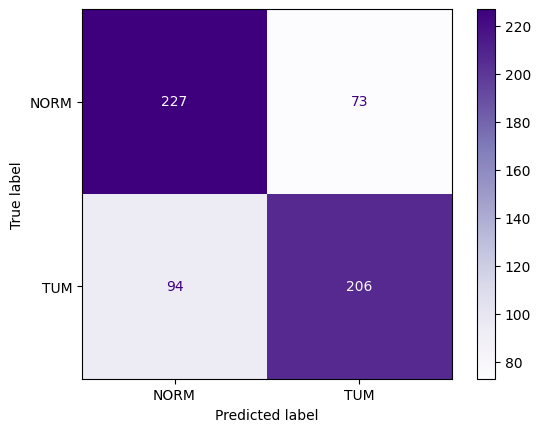

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(yte_num, pred_test)   # filas = real, columnas = predicho; orden [0=NORM, 1=TUM]
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORM","TUM"])
disp.plot(cmap="Purples", values_format="d"); plt.show()